# CSE2530 Computational Intelligence
## Assignment 3: Reinforcement Learning

<div style="background-color:#f1be3e">

_Fill in your group number **from Brightspace**, names, and student numbers._
    
|    Group   |           X          |
|------------|----------------------|
| Student A  |        XXXXXXX       |
| Student B  |        XXXXXXX       |
| Student C  |        XXXXXXX       |
| Student D  |        XXXXXXX       |

#### Imports

In [2]:
"""
You may only use numpy to implement your algorithms
You can make use of any other libraries for miscellaneous functions, e.g. to create the visual aids.
Put all of your imports in this code block.
"""
import matplotlib.pyplot as plt
import numpy as np
import random
from typing import Dict, List
from tqdm import tqdm

"""
The following classes are fully implemented in their own files and you should not change them.
Nonetheless, we encourage you to check how they work; this will help you get started.
"""
from Agent import Agent
from Maze import Maze
from QTable import QTable
from State import State
from Action import Action
np.random.seed(19)
random.seed(19)


## 2. Navigating in the Supermarket
### 2.1 Development
#### Question 1

In [4]:
class ExplorationStrategy:
    def __init__(self, q_table: QTable):
        self.q_table = q_table


    def random(self, agent: Agent, maze: Maze):
        """
        The random exploration strategy selects a random action uniformly at random
        from the set of all valid actions.
        """
        actions = agent.get_valid_actions(maze)
        action = actions[np.random.randint(len(actions))]
        return agent.step(action, maze), action

    def e_greedy(self, agent: Agent,  maze: Maze, eps: float):
        """
        The e-greedy exploration strategy selects a random action with probability eps,
        and the action with highest q-value with probability 1 - eps. A value of epsilon
        close to 0 favours exploitation, while a value close to 1 favours exploration.
        """
        actions = agent.get_valid_actions(maze)
        if np.random.rand() < eps:
            return self.random(agent,maze)
        else:
            scores = [self.q_table.get_q(agent.get_state(maze),a) for a in actions]
            action = actions[np.argmax(scores)]
            return agent.step(action, maze), action

    def boltzmann(self, agent: Agent, maze: Maze, temperature: float):
        """
        The Boltzmann exploration strategy assigns a probability to each action based on its estimated q-values.
        A large value of the temperature encourages exploration, and as the temperature declines over time,
        exploitation is favoured. 
        """
        actions = agent.get_valid_actions(maze)
        scores = np.array([self.q_table.get_q(agent.get_state(maze),a)/ temperature for a in actions])
        scores_stable = scores - np.max(scores)
        output = np.exp(scores_stable) 
        output /= np.sum(output)
        action = np.random.choice(actions, p=output)
        return agent.step(action, maze), action

<div style="background-color:#f1be3e">

Random has no hyperparameters nor an interesting implementation, we just pick a random action and take it.

E-greedy calls random with a probablity of the hyperparameter epsilon, for which we choose 0.1 as this seems like it would allow for enough exploration to find a good path while also making sure that our solutions don't get worse on average as we still pick our current best path with 0.9 probability.

Boltzmann takes a path with the probability proportional to its Q-score, similarly to roulette wheel in genetic algorithms. We can tune the temperature to encourage exploration (for high temperatures) or exploitation (low temperatures). We will pick T = 1.5 to encourage exploration in order to help prevent local minima, while still reasonably converging to a good solution.

For sufficient exploration we can use either e-greedy or boltzmann. Random does not have any exploitation and will thus not converge to a good solution, e-greedy/boltzmann with epsilon = 0.1 and temperature = 1.5 respectively have sufficient exploration and exploitation to find paths towards the goal.

#### Question 2

100%|██████████| 300/300 [00:26<00:00, 11.13it/s]


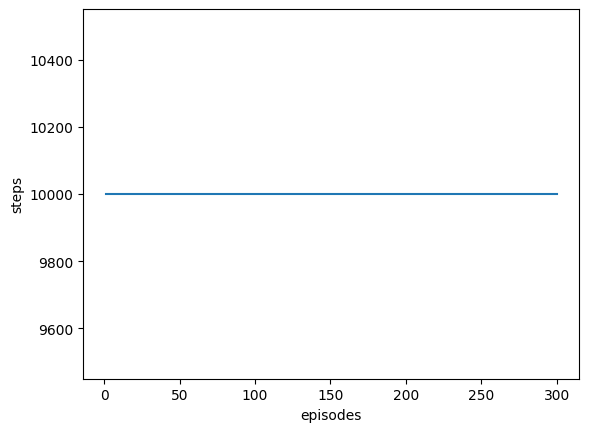

In [ ]:
# Create a Maze instance.
maze = Maze("./../data/easy_maze.txt")
maze.set_reward(x=9, y=9, reward=10)
maze.set_terminal(x=9, y=9)
# Create an Agent.
agent = Agent(start_x=0, start_y=0)
# Create a QTable.
states = maze.get_all_states()
actions = [Action(id) for id in ["up", "down", "left", "right"]]
q_table = QTable(states, actions)
# Create an ExplorationStrategy.
exploration_strategy = ExplorationStrategy(q_table)
# Create a learner.
params = {"lr": 0.7, "gamma": 0.9}
# learner = QLearning(q_table, params)


# Hyper-parameters.
n_episodes = 300
episode_lengths = []
episode_rewards = []
maxsteps = 10000
steps = np.zeros(n_episodes)
for episode in tqdm(range(n_episodes)):
    done = False
    agent.reset()
    while not done and steps[episode] < maxsteps:
        state = agent.get_state(maze)
        (next,reward,done),action = exploration_strategy.e_greedy(agent, maze, 0.1)
        valid_actions = agent.get_valid_actions(maze)
        steps[episode] += 1
        #learner.learn(valid_actions,state,action,next,reward,done)
plt.xlabel("episodes")
plt.ylabel("steps")
linspace = np.linspace(1,n_episodes, n_episodes)
plt.plot(linspace,steps)

<div style="background-color:#f1be3e">

We get the current state, and the valid actions from that current state, take an e-greedy step (boltzmann would also be possible, both step functions are okay), and we conceptually pass it to the learning method that we will implement later so that we can update the q-table. 

We would only stop when reaching the done state, but randomly walking through a 25x15 maze will take an insanely long time to get to that state, so we count the steps per episode and terminate when we take 10k steps. As we can see by the plot, we never take reach the goal 10k steps. This makes sense as our model isn't trained.

#### Question 3

<div style="background-color:#f1be3e">

_Put your extra code blocks above (if any) and write your answer here._  
_You may want to directly modify the cycle in Question 2._

#### Question 4

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 5

In [ ]:
class QLearning:

    def __init__(self, q_table: QTable, params: Dict[str, float]) -> None:
        self.q_table = q_table
        self.params = params

    def learn(self, possible_actions: List[Action], state: State, action: Action,
               next_state: State, reward: int, done: bool) -> None:
        qmax = np.max(np.array([q_table.get_q(next_state,a) for a in possible_actions]))
        current = q_table.get_q(state,action)
        value = current + params["lr"]*(reward + params["gamma"]*qmax - current)
        q_table.set_q(state,action,value)

In [11]:
class SARSA:

    def __init__(self, q_table: QTable, params: Dict[str, float]) -> None:
        self.q_table = q_table
        self.params = params
    
    def learn(self, state: State, action: Action, next_state: State, next_action: Action,
               reward: float, done: bool) -> None:
        qmax = q_table.get_q(next_state,next_action)
        current = q_table.get_q(state,action)
        value = current + params["lr"]*(reward + params["gamma"]*qmax - current)

<div style="background-color:#f1be3e">

_Put your extra code blocks above (if any) and write your answer here._

#### Question 6

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 7

<div style="background-color:#f1be3e">

_Write your answer here._

### 2.2 Optimization
#### Question 8

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 9

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 10

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 11

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 12

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

### 2.3 Introducing More Rewards
#### Question 13

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 14

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 15

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 16

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

## 3. Open Questions
### 3.1 Reflection
#### Question 17

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 18

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 19

<div style="background-color:#f1be3e">

_Write your answer here._

### 3.2 Pen and Paper
#### Question 20

<div style="background-color:#f1be3e">

_Write your answer here. You can also choose to simply include a photo of your solution._

#### Question 21

<div style="background-color:#f1be3e">

_Write your answer here. You can also choose to simply include a photo of your solution._

#### Question 22

<div style="background-color:#f1be3e">

_Write your answer here. You can also choose to simply include a photo of your solution._

### 3.3 Division of Work

#### Question 23

<div style="background-color:#f1be3e">


|          Component          |  Name A   |  Name B   |  Name C   |  Name D   |
|-----------------------------|-----------|-----------|-----------|-----------|
| Code (design)               |     A     |     B     |     C     |     D     |
| Code (implementation)       |     A     |     B     |     C     |     D     |
| Code (validation)           |     A     |     B     |     C     |     D     |
| Experiments (execution)     |     A     |     B     |     C     |     D     |
| Experiments (analysis)      |     A     |     B     |     C     |     D     |
| Experiments (visualization) |     A     |     B     |     C     |     D     |
| Report (original draft)     |     A     |     B     |     C     |     D     |
| Report (reviewing, editing) |     A     |     B     |     C     |     D     |

### References

<div style="background-color:#f1be3e">

**If you made use of any non-course resources, cite them below.**